# **Capstone Project: Diabetespedia**

- **ID Tim:** CC25-CF020
- **Anggota Tim:**
  - (ML) MC172D5X1394 - Maria Stephanie Rayadi
  - (ML) MC172D5X1392 - Richelle Vania Thionanda
  - (ML) MC172D5X1395 - Valencia Sutio
  - (FEBE) FC172D5X0625 - Claresta Ratna Cong
  - (FEBE) FC172D5X0628 - Lisa

## **Pemahaman Struktur Dataset**

**Pemahaman Dataset:**

Dataset ini bertujuan untuk menyediakan data yang relevan untuk membangun model prediksi diabetes. Data ini biasanya dikumpulkan dari catatan medis atau survei kesehatan. Setiap baris dalam dataset merepresentasikan data dari satu individu.

**Fitur-fitur (Kolom) dalam Dataset:**

- Age: Usia individu. Usia merupakan faktor risiko yang signifikan untuk diabetes.
- Gender: Jenis kelamin individu (misalnya, Laki-laki, Perempuan).
- BMI (Body Mass Index): Indeks massa tubuh, yang dihitung dari berat dan tinggi badan. BMI yang tinggi sering dikaitkan dengan risiko diabetes.
- Hypertension: Indikator apakah individu menderita hipertensi (tekanan darah tinggi) atau tidak (biasanya dalam bentuk biner: 0 atau 1). Hipertensi merupakan faktor risiko lain untuk diabetes.
- Heart Disease: Indikator apakah individu menderita penyakit jantung atau tidak (biasanya dalam bentuk biner: 0 atau 1). Penyakit jantung seringkali terkait dengan diabetes.
- Smoking History: Riwayat merokok individu. Merokok juga merupakan faktor risiko untuk diabetes.
- HbA1c Level: Tingkat hemoglobin A1c, yang merupakan ukuran rata-rata gula darah dalam beberapa bulan terakhir. Ini adalah indikator penting untuk mendiagnosis diabetes.
- Blood Glucose Level: Tingkat glukosa darah pada saat pengukuran. Ini juga merupakan indikator penting untuk mendiagnosis diabetes.
- Diabetes: Ini adalah target variabel atau label yang ingin diprediksi. Biasanya dalam bentuk biner (0 atau 1), di mana 1 menunjukkan individu menderita diabetes, dan 0 menunjukkan sebaliknya.

## **Import Semua Packages/Library**

In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.1 MB/s eta 0:00:00


In [ ]:
# Mengimpor library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import io
import requests
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn untuk pre-processing, splitting, dan evaluasi
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,  classification_report,  roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import SelectKBest, f_classif, chi2
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from sklearn.utils import class_weight
from sklearn.decomposition import PCA
from imblearn.combine import SMOTETomek

# TensorFlow untuk membangun model Neural Network (sesuai saran gambar)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Conv1D, MaxPooling1D, Flatten, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import keras_tuner as kt
from keras_tuner import RandomSearch

## **Data Loading**

In [ ]:
url = "https://raw.githubusercontent.com/lissxa/DiabetesPedia/development/diabetes_prediction_dataset.csv"
response = requests.get(url)
df = pd.read_csv(io.StringIO(response.text))

print("Data loaded successfully with shape:", df.shape)
print(df.head())

Data loaded successfully with shape: (100000, 9)
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


Data Loading dilakukan dengan menggunakan library pandas. Data diambil dari URL yang mengarah ke file CSV mengenai prediksi diabetes. Setelah berhasil memuat data, informasi mengenai bentuk DataFrame ditampilkan, yang menunjukkan bahwa dataset ini memiliki 100,000 baris dan 9 kolom. Hal ini menunjukkan bahwa dataset cukup besar untuk analisis lebih lanjut, dan penggunaan fungsi head() memberikan gambaran awal tentang struktur data.

## **Exploratory Data Analysis (EDA)**

In [ ]:
# Menampilkan informasi dataset (tipe data, non-null counts)
print("\nInformasi dataset:")
df.info()


Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


Dari hasil menunjukkan informasi lebih mendalam tentang dataset menggunakan fungsi info(). Data ini terdiri dari 10 kolom, termasuk kolom untuk gender, usia, hipertensi, penyakit jantung, serta kolom numerik seperti level HbA1c dan kadar glukosa darah. Dalam analisis ini, semua kolom memiliki nilai non-null, yang berarti tidak ada data yang hilang. Ini mangkah penting dalam EDA, karena data yang lengkap lebih dapat diandalkan untuk analisis selanjutnya.

In [ ]:
# Menampilkan statistik deskriptif untuk kolom numerik
print("\nStatistik deskriptif dataset:")
print(df.describe())


Statistik deskriptif dataset:
                 age  hypertension  heart_disease            bmi  \
count  100000.000000  100000.00000  100000.000000  100000.000000   
mean       41.885856       0.07485       0.039420      27.320767   
std        22.516840       0.26315       0.194593       6.636783   
min         0.080000       0.00000       0.000000      10.010000   
25%        24.000000       0.00000       0.000000      23.630000   
50%        43.000000       0.00000       0.000000      27.320000   
75%        60.000000       0.00000       0.000000      29.580000   
max        80.000000       1.00000       1.000000      95.690000   

         HbA1c_level  blood_glucose_level       diabetes  
count  100000.000000        100000.000000  100000.000000  
mean        5.527507           138.058060       0.085000  
std         1.070672            40.708136       0.278883  
min         3.500000            80.000000       0.000000  
25%         4.800000           100.000000       0.000000  
50

Dari hasil menampilkan statistik deskriptif dari kolom numerik dalam dataset. Ini mencakup ukuran seperti rata-rata, standar deviasi, nilai minimum, dan maksimum untuk kolom seperti usia, level HbA1c, dan kadar glukosa darah. Statistik ini memberikan wawasan penting tentang distribusi data dan membantu dalam memahami karakteristik populasi yang dianalisis, seperti kisaran kadar glukosa yang ada di dalam dataset.

In [ ]:
# Memeriksa jumlah nilai unik per kolom
print("\nJumlah nilai unik per kolom:")
for column in df.columns:
    print(f"{column}: {df[column].unique()}")


Jumlah nilai unik per kolom:
gender: ['Female' 'Male' 'Other']
age: [80.   54.   28.   36.   76.   20.   44.   79.   42.   32.   53.   78.
 67.   15.   37.   40.    5.   69.   72.    4.   30.   45.   43.   50.
 41.   26.   34.   73.   77.   66.   29.   60.   38.    3.   57.   74.
 19.   46.   21.   59.   27.   13.   56.    2.    7.   11.    6.   55.
  9.   62.   47.   12.   68.   75.   22.   58.   18.   24.   17.   25.
  0.08 33.   16.   61.   31.    8.   49.   39.   65.   14.   70.    0.56
 48.   51.   71.    0.88 64.   63.   52.    0.16 10.   35.   23.    0.64
  1.16  1.64  0.72  1.88  1.32  0.8   1.24  1.    1.8   0.48  1.56  1.08
  0.24  1.4   0.4   0.32  1.72  1.48]
hypertension: [0 1]
heart_disease: [1 0]
smoking_history: ['never' 'No Info' 'current' 'former' 'ever' 'not current']
bmi: [25.19 27.32 23.45 ... 59.42 44.39 60.52]
HbA1c_level: [6.6 5.7 5.  4.8 6.5 6.1 6.  5.8 3.5 6.2 4.  4.5 9.  7.  8.8 8.2 7.5 6.8]
blood_glucose_level: [140  80 158 155  85 200 145 100 130 160 126 1

Dari hasil menunjukkan analisis mengenai jumlah nilai unik per kolom. Ini mencakup kolom kategorikal seperti gender dan riwayat merokok, serta kolom numerik. Dengan melihat jumlah nilai unik, kita dapat memahami variasi dalam data, seperti berapa banyak kategori yang ada dalam kolom gender (misalnya, 'Female', 'Male', 'Other'). Informasi ini sangat berguna untuk merencanakan analisis lebih lanjut, termasuk model prediksi yang mungkin akan diterapkan.


Distribusi kolom target (Diabetes):
Nama-nama kolom dalam DataFrame: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']
diabetes
0    91500
1     8500
Name: count, dtype: int64

Proporsi kolom target (Diabetes):
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64


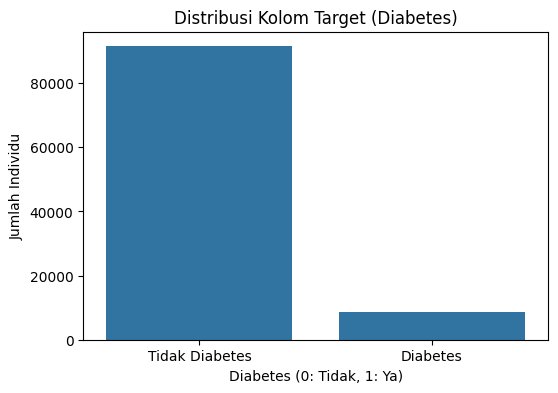

In [ ]:
# Menampilkan distribusi kolom target
print("\nDistribusi kolom target (Diabetes):")
print("Nama-nama kolom dalam DataFrame:", df.columns.tolist())

print(df['diabetes'].value_counts())
print("\nProporsi kolom target (Diabetes):")
print(df['diabetes'].value_counts(normalize=True))

# Visualisasi distribusi kolom target
plt.figure(figsize=(6, 4))
sns.countplot(x='diabetes', data=df)
plt.title('Distribusi Kolom Target (Diabetes)')
plt.xlabel('Diabetes (0: Tidak, 1: Ya)')
plt.ylabel('Jumlah Individu')
plt.xticks([0, 1], ['Tidak Diabetes', 'Diabetes'])
plt.show()

- Dalam analisis ini, fokus utama adalah kolom target yang menunjukkan keberadaan diabetes dalam dataset. Hasil distribusi menunjukkan bahwa dari total 100,000 individu, 91,500 (91.5%) tidak menderita diabetes (0), sementara 8,500 (8.5%) lainnya terdiagnosis diabetes (1). Ini menunjukkan bahwa dataset ini memiliki ketidakseimbangan kelas yang signifikan, di mana mayoritas individu tidak menderita diabetes.

- Proporsi masing-masing kelas (0 dan 1) juga dihitung, yang menegaskan bahwa hanya 8.5% dari populasi yang memiliki diabetes, sedangkan 91.5% tidak. Ketidakseimbangan ini penting untuk dipertimbangkan saat membangun model prediksi, karena dapat mempengaruhi akurasi dan kinerja model.

- Visualisasi menggunakan seaborn untuk membuat grafik batang distribusi kolom target memberikan gambaran visual yang jelas tentang perbandingan jumlah individu di masing-masing kelas. Grafik menunjukkan bahwa jumlah individu yang tidak menderita diabetes jauh lebih besar dibandingkan dengan mereka yang menderita diabetes. Judul, label sumbu, dan pengaturan tampilan lainnya membantu dalam menjelaskan konteks dari visualisasi ini.

## **Visualisasi Distribusi Fitur**

In [ ]:
# Pisahkan kolom kategorikal dan numerik
categorical_features = ['gender', 'hypertension', 'heart_disease', 'smoking_history']
numerical_features = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
# Target variable
target_variable = 'diabetes'

--- Visualisasi Distribusi Fitur Kategorikal ---


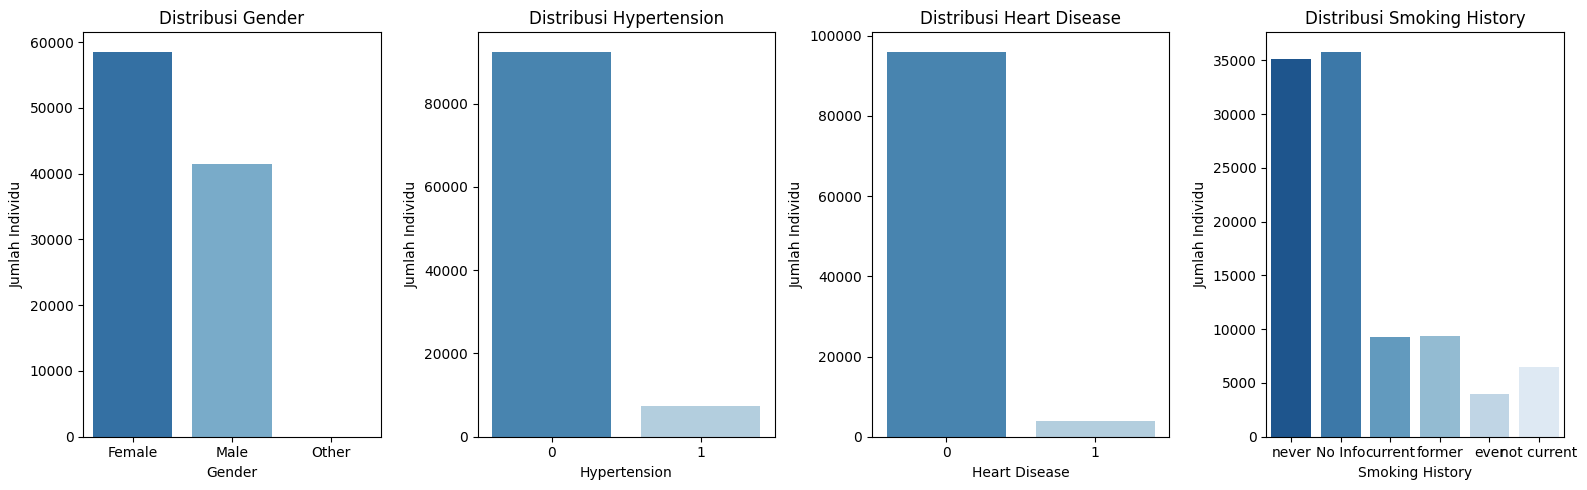


--- Visualisasi Distribusi Fitur Numerik ---


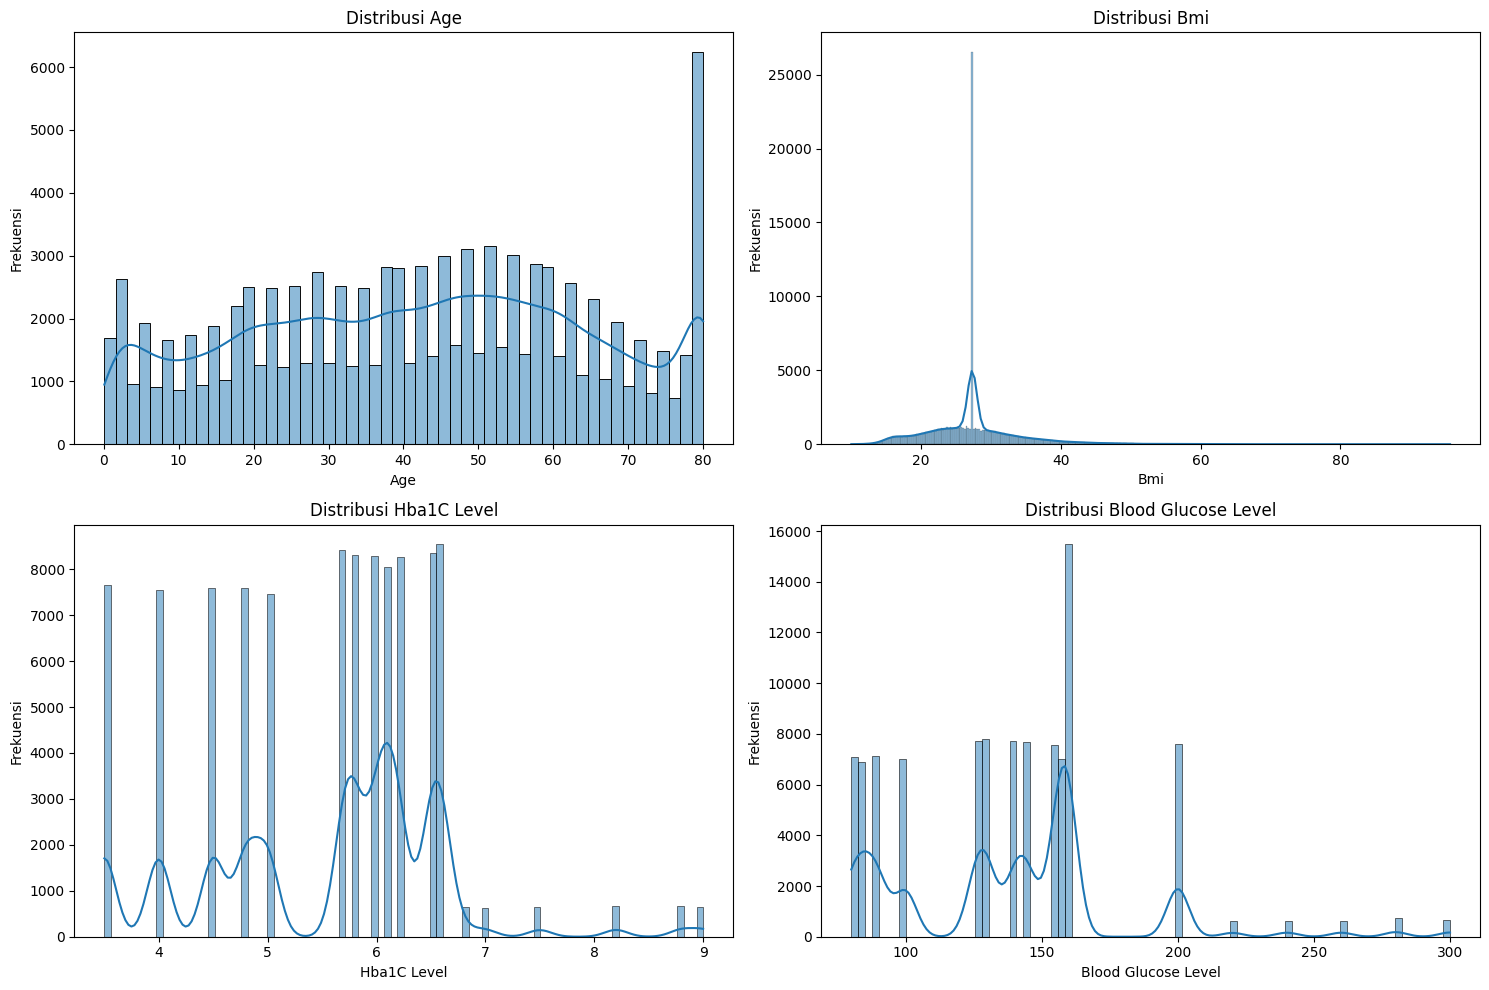


--- Distribusi Fitur Kategorikal berdasarkan Status Diabetes ---


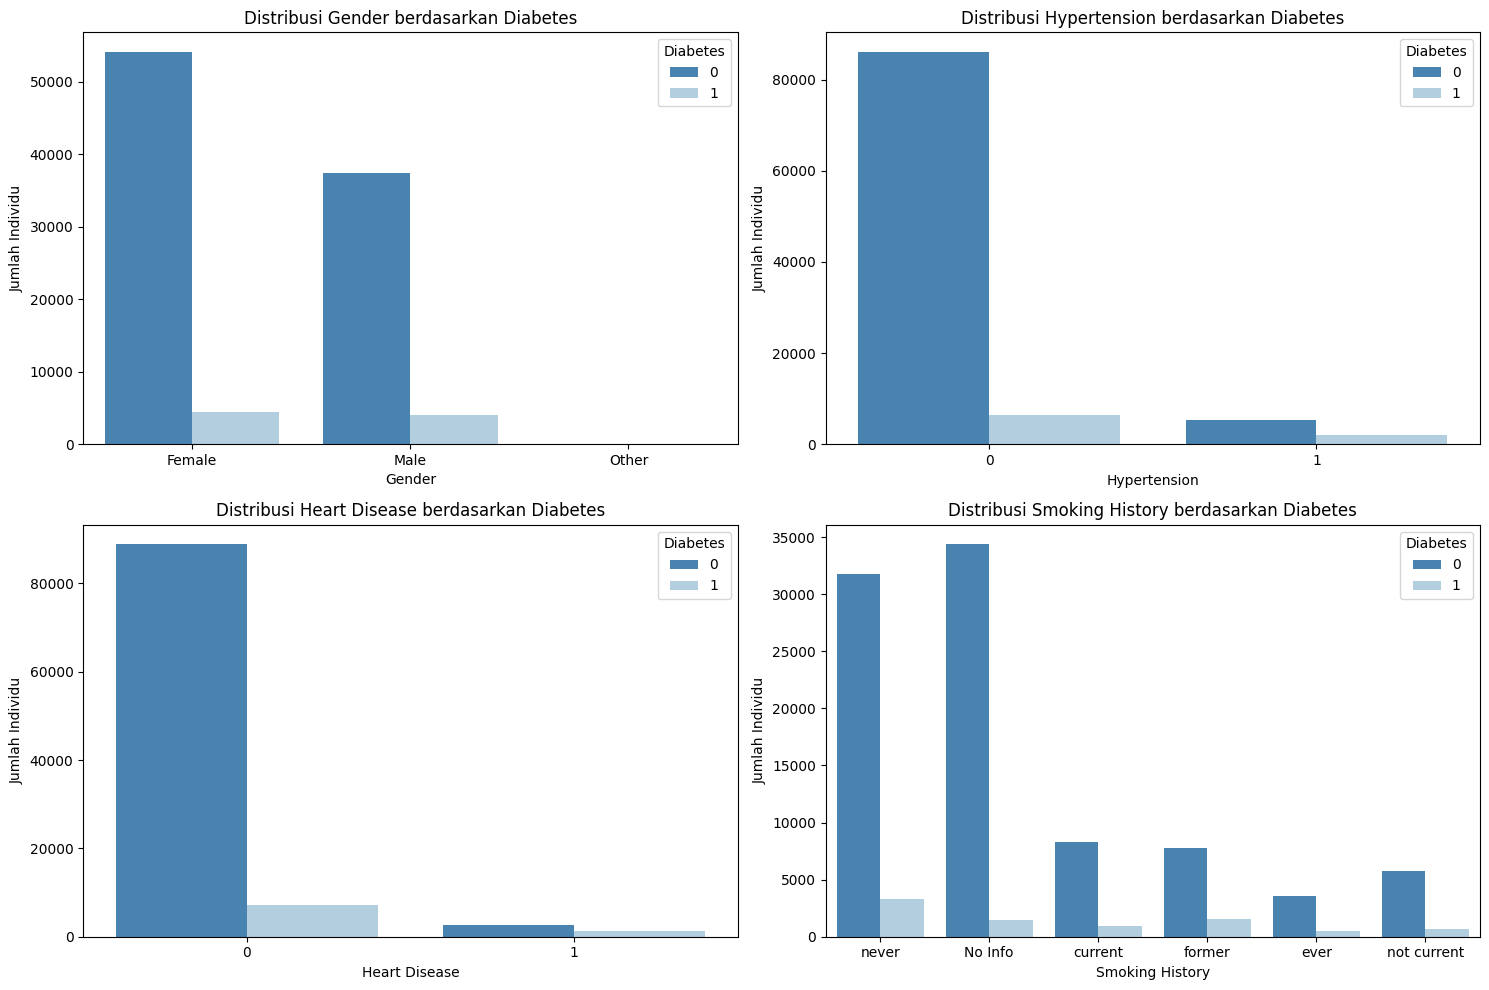


Visualisasi Data Telah Selesai.


In [ ]:
# Visualisasi Distribusi Fitur Kategorikal ---
print("--- Visualisasi Distribusi Fitur Kategorikal ---")
num_categorical_plots = len(categorical_features)
# Menentukan ukuran figure secara dinamis: lebar 4 inch per kolom, tinggi 5 inch
plt.figure(figsize=(num_categorical_plots * 4, 5))

for i, feature in enumerate(categorical_features):
    # Menggunakan num_categorical_plots sebagai jumlah kolom agar pas
    plt.subplot(1, num_categorical_plots, i + 1)
    sns.countplot(x=feature, data=df, palette='Blues_r') # Menambahkan palette
    plt.title(f'Distribusi {feature.replace("_", " ").title()}') # Judul lebih rapi
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel('Jumlah Individu')

plt.tight_layout() # Mengatur layout agar tidak tumpang tindih
plt.show()


# Visualisasi Distribusi Fitur Numerik ---
print("\n--- Visualisasi Distribusi Fitur Numerik ---")
num_numerical_plots = len(numerical_features)
# Mengatur grid untuk fitur numerik (misal 2x2 jika 4 fitur, atau menyesuaikan)
nrows_num = (num_numerical_plots + 1) // 2 # Akan jadi 2 untuk 3-4 fitur
ncols_num = 2
plt.figure(figsize=(15, nrows_num * 5)) # Ukuran figure disesuaikan

for i, feature in enumerate(numerical_features):
    plt.subplot(nrows_num, ncols_num, i + 1)
    sns.histplot(df[feature], kde=True, palette='Blues_r') # kde=True untuk kepadatan estimasi kernel
    plt.title(f'Distribusi {feature.replace("_", " ").title()}')
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()


# Distribusi Fitur Kategorikal terhadap Target ('diabetes') ---
print("\n--- Distribusi Fitur Kategorikal berdasarkan Status Diabetes ---")
# Jumlah plot akan sama dengan jumlah fitur kategorikal
num_categorical_target_plots = len(categorical_features)
# Mengatur grid untuk visualisasi terhadap target (misal 2x2 jika 4 fitur)
nrows_cat_target = (num_categorical_target_plots + 1) // 2
ncols_cat_target = 2
plt.figure(figsize=(15, nrows_cat_target * 5))

for i, feature in enumerate(categorical_features):
    plt.subplot(nrows_cat_target, ncols_cat_target, i + 1)
    # Menggunakan hue=target_variable untuk membandingkan distribusi berdasarkan target
    sns.countplot(x=feature, hue=target_variable, data=df, palette='Blues_r')
    plt.title(f'Distribusi {feature.replace("_", " ").title()} berdasarkan Diabetes')
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel('Jumlah Individu')
    # Label legend sudah di-map di atas: 0='Tidak', 1='Ya'
    # Jika Anda ingin kontrol lebih, pastikan value_counts dari df['diabetes']
    # dan sesuaikan labels di plt.legend() jika perlu.
    plt.legend(title='Diabetes') # Menggunakan title dari hue secara otomatis

plt.tight_layout()
plt.show()

print("\nVisualisasi Data Telah Selesai.")

### Visualisasi Distribusi Fitur Kategorikal
Dari hasil menampilkan distribusi fitur kategorikal seperti gender, hipertensi, penyakit jantung, dan riwayat merokok. Setiap subplot menunjukkan jumlah individu berdasarkan kategori. Dari visualisasi ini, terlihat bahwa:

- **Gender:** Terdapat lebih banyak wanita (Female) dibandingkan pria (Male) dan kategori lainnya.
- **Hipertensi:** Lebih banyak individu yang tidak mengalami hipertensi (0) dibandingkan yang mengalaminya (1).
- **Penyakit Jantung:** Sebagian besar individu tidak memiliki riwayat penyakit jantung (0).
- **Riwayat Merokok:** Kategori 'never' dan 'no info' memiliki jumlah terbanyak, menunjukkan banyak individu yang tidak merokok atau tidak memiliki informasi tentang riwayat merokok mereka.

### Visualisasi Distribusi Fitur Numerik
Hasil menunjukkan distribusi fitur numerik seperti usia (age), indeks massa tubuh (BMI), level HbA1c, dan kadar glukosa darah. Hasilnya menunjukkan:

- **Usia:** Distribusi usia tampak merata, tetapi ada puncak signifikan di usia 80, menunjukkan konsentrasi individu di usia tersebut.
- **BMI:** Distribusi menunjukkan banyak individu memiliki BMI di sekitar 25 hingga 35, tetapi ada puncak tinggi di sekitar 30, menunjukkan banyak individu dengan BMI yang berisiko.
- **HbA1c Level dan Blood Glucose Level:** Distribusi kedua fitur ini menunjukkan banyak nilai terpusat di kisaran tertentu, dengan puncak yang menunjukkan konsentrasi individu pada level glukosa tertentu.

### Distribusi Fitur Kategorikal Berdasarkan Status Diabetes
Hasil menunjukkan distribusi fitur kategorikal berdasarkan status diabetes. Ini memberikan informasi tambahan tentang bagaimana faktor-faktor ini terkait dengan diabetes:

- **Gender dan Hipertensi:** Jumlah individu dengan diabetes lebih banyak pada pria dan mereka yang mengalami hipertensi.
- **Penyakit Jantung dan Riwayat Merokok:** Individu dengan riwayat penyakit jantung memiliki proporsi yang lebih tinggi terkena diabetes, sedangkan riwayat merokok menunjukkan variasi, tetapi tidak ada kategori yang dominan.

--- Heatmap Korelasi Antar Fitur Numerik ---


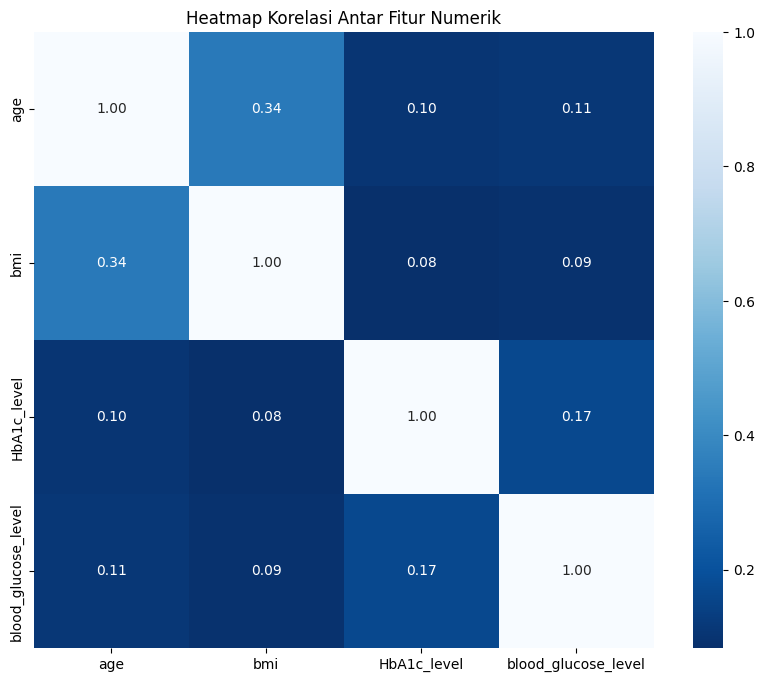


--- Hubungan Fitur Kategorikal dengan Diabetes ---


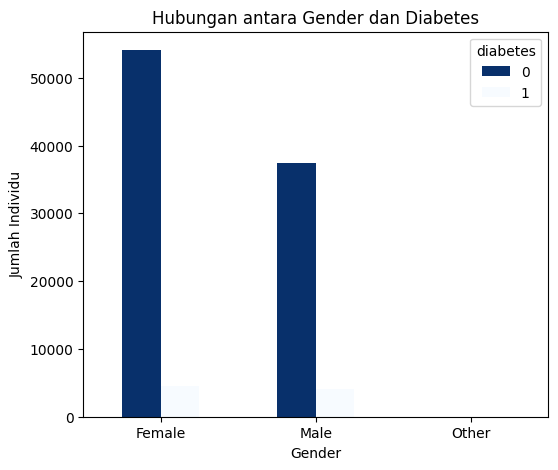

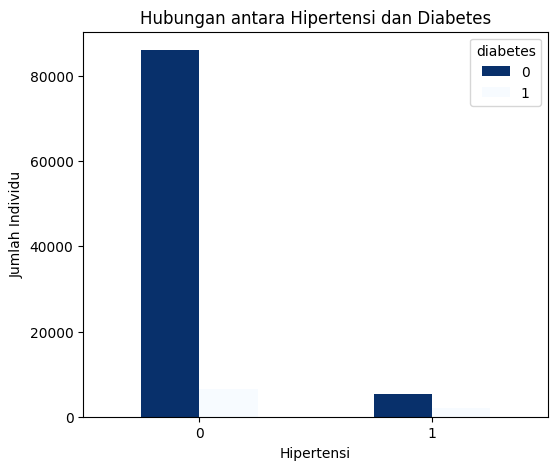

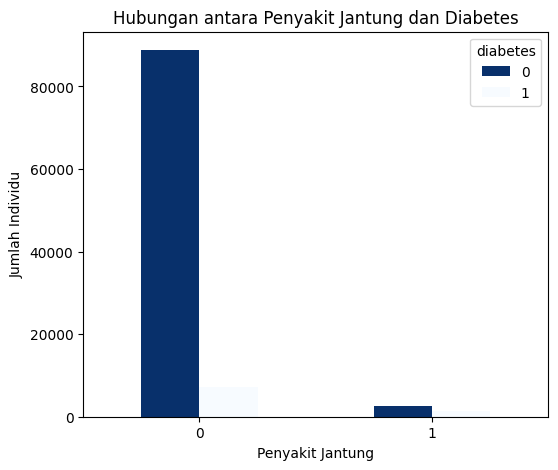

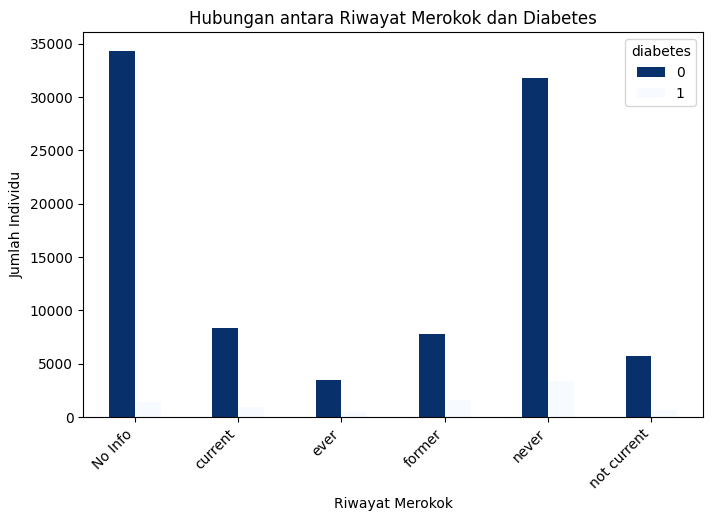


Analisis Korelasi dan Crosstab Selesai.


In [ ]:
# --- Visualisasi Korelasi dan Hubungan Fitur ---

# Buat heatmap untuk korelasi antar fitur numerik
print("--- Heatmap Korelasi Antar Fitur Numerik ---")
plt.figure(figsize=(10, 8))
# Memastikan hanya kolom numerik yang digunakan untuk korelasi
sns.heatmap(df[numerical_features].corr(), annot=True, cmap='Blues_r', fmt=".2f")
plt.title('Heatmap Korelasi Antar Fitur Numerik')
plt.show()

print("\n--- Hubungan Fitur Kategorikal dengan Diabetes ---")

# Untuk fitur kategorikal, analisis hubungan dengan target dilakukan dengan cross-tabulation atau count plots.

# Contoh: Crosstab antara Gender dan Diabetes
plt.figure(figsize=(6, 5)) # Atur ukuran figure untuk setiap plot
pd.crosstab(df['gender'], df['diabetes']).plot(kind='bar', ax=plt.gca(), cmap='Blues_r') # Menggunakan ax=plt.gca()
plt.title('Hubungan antara Gender dan Diabetes')
plt.xlabel('Gender')
plt.ylabel('Jumlah Individu')
plt.xticks(rotation=0) # Pastikan label tidak berputar
plt.show()

# Contoh: Crosstab antara Hypertension dan Diabetes
plt.figure(figsize=(6, 5))
pd.crosstab(df['hypertension'], df['diabetes']).plot(kind='bar', ax=plt.gca(), cmap='Blues_r')
plt.title('Hubungan antara Hipertensi dan Diabetes')
# Label sumbu X sudah di-map ke 'No'/'Yes', jadi tidak perlu (0: Tidak, 1: Ya)
plt.xlabel('Hipertensi')
plt.ylabel('Jumlah Individu')
plt.xticks(rotation=0)
plt.show()

# Contoh: Crosstab antara Heart Disease dan Diabetes
plt.figure(figsize=(6, 5))
# PERBAIKAN: Mengganti 'heart_Disease' menjadi 'heart_disease' (huruf kecil 'd')
pd.crosstab(df['heart_disease'], df['diabetes']).plot(kind='bar', ax=plt.gca(), cmap='Blues_r')
plt.title('Hubungan antara Penyakit Jantung dan Diabetes')
# Label sumbu X sudah di-map ke 'No'/'Yes', jadi tidak perlu (0: Tidak, 1: Ya)
plt.xlabel('Penyakit Jantung')
plt.ylabel('Jumlah Individu')
plt.xticks(rotation=0)
plt.show()

# Contoh: Crosstab antara Smoking History dan Diabetes
plt.figure(figsize=(8, 5)) # Ukuran figure disesuaikan untuk kategori lebih banyak
pd.crosstab(df['smoking_history'], df['diabetes']).plot(kind='bar', ax=plt.gca(), cmap='Blues_r')
plt.title('Hubungan antara Riwayat Merokok dan Diabetes')
plt.xlabel('Riwayat Merokok')
plt.ylabel('Jumlah Individu')
# Rotasi label sumbu X jika kategori terlalu banyak agar tidak tumpang tindih
plt.xticks(rotation=45, ha='right')
plt.show()

print("\nAnalisis Korelasi dan Crosstab Selesai.")

### Heatmap Korelasi Antar Fitur Numerik
Hasil menampilkan heatmap yang menggambarkan korelasi antar fitur numerik dalam dataset. Dari heatmap ini, terlihat bahwa:

- **Korelasi Tinggi:** Terdapat korelasi positif yang cukup signifikan antara HbA1c_level dan blood_glucose_level, dengan nilai korelasi mendekati 1. Ini menunjukkan bahwa semakin tinggi kadar glukosa darah, semakin tinggi pula level HbA1c.
- **Korelasi Lemah:**  Fitur age, bmi, dan HbA1c_level memiliki korelasi yang lebih rendah dengan blood_glucose_level, menunjukkan bahwa faktor-faktor ini mungkin tidak secara langsung mempengaruhi kadar glukosa darah.

### Hubungan antara Gender dan Diabetes
Hasil menampilkan hubungan antara gender dan status diabetes. Dari analisis ini, terlihat bahwa:

- **Distribusi Gender:** Jumlah individu yang tidak menderita diabetes (0) jauh lebih banyak dibandingkan yang menderita diabetes (1) pada kedua kategori gender. Namun, proporsi pria (Male) yang menderita diabetes tampak lebih tinggi dibandingkan wanita (Female), meskipun jumlah keseluruhan wanita lebih banyak.

### Hubungan antara Hipertensi dan Diabetes
Hasil menampilkan hubungan antara hipertensi dan status diabetes. Hasil menunjukkan bahwa:

- **Distribusi Hipertensi:** Sebagian besar individu yang tidak mengalami hipertensi (0) juga tidak menderita diabetes. Sebaliknya, proporsi individu dengan hipertensi yang menderita diabetes (1) terlihat lebih signifikan, menunjukkan bahwa hipertensi dapat menjadi faktor risiko untuk diabetes.

### Hubungan antara Riwayat Merokok dan Diabetes
Hasil menampilkan hubungan antara riwayat merokok dan status diabetes. Hasil menunjukkan:

- **Distribusi Riwayat Merokok:** Kategori 'No Info' dan 'never' memiliki jumlah individu yang cukup tinggi dan proporsi yang tidak menderita diabetes. Namun, kategori 'current' dan 'ever' menunjukkan lebih banyak individu yang menderita diabetes, meskipun jumlahnya tidak sebanyak kategori lainnya. Ini menunjukkan bahwa riwayat merokok mungkin juga berkontribusi terhadap risiko diabetes.

## **Pre-Processing**

### Deteksi dan Penanganan Missing Values

In [ ]:
# Cek missing values
print("\nJumlah missing values per kolom:")
print(df.isnull().sum())

# Penanganan Missing Values
df.dropna(inplace=True)
print("\nShape after dropping missing values:", df.shape)


Jumlah missing values per kolom:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Shape after dropping missing values: (100000, 9)


Hasil menunjukkan proses deteksi dan penanganan missing values dalam dataset. Dari hasil analisis, terlihat bahwa tidak ada kolom yang memiliki nilai yang hilang, yang ditunjukkan oleh jumlah missing values yang sama dengan nol untuk semua kolom. Setelah proses pembersihan, bentuk dataset tetap 100,000 baris dan 9 kolom. Ini menunjukkan bahwa dataset sudah bersih dari missing values, sehingga siap untuk analisis lebih lanjut.

### Deteksi dan Penanganan Duplikat Data

In [ ]:
# Cek data duplikat
print("\nJumlah data duplikat:", df.duplicated().sum())

# Penanganan data duplikat: Hapus baris duplikat
df.drop_duplicates(inplace=True)
print("\nShape after dropping duplicates:", df.shape)


Jumlah data duplikat: 3854

Shape after dropping duplicates: (96146, 9)


Hasil menunjukkan proses deteksi data duplikat dalam dataset. Hasil menunjukkan bahwa terdapat 3,854 baris duplikat. Setelah menghapus baris-baris tersebut, bentuk dataset berkurang menjadi 96,146 baris dengan tetap mempertahankan 9 kolom. Penanganan data duplikat ini penting untuk memastikan keakuratan analisis, karena data yang tidak unik dapat menyebabkan bias dalam hasil.

### Deteksi dan Penanganan Outlier


Deteksi Outlier menggunakan IQR:
Jumlah outlier (IQR): 7951
Persentase outlier (IQR): 8.269714808728393 %

Visualisasi Outlier (Box Plot):


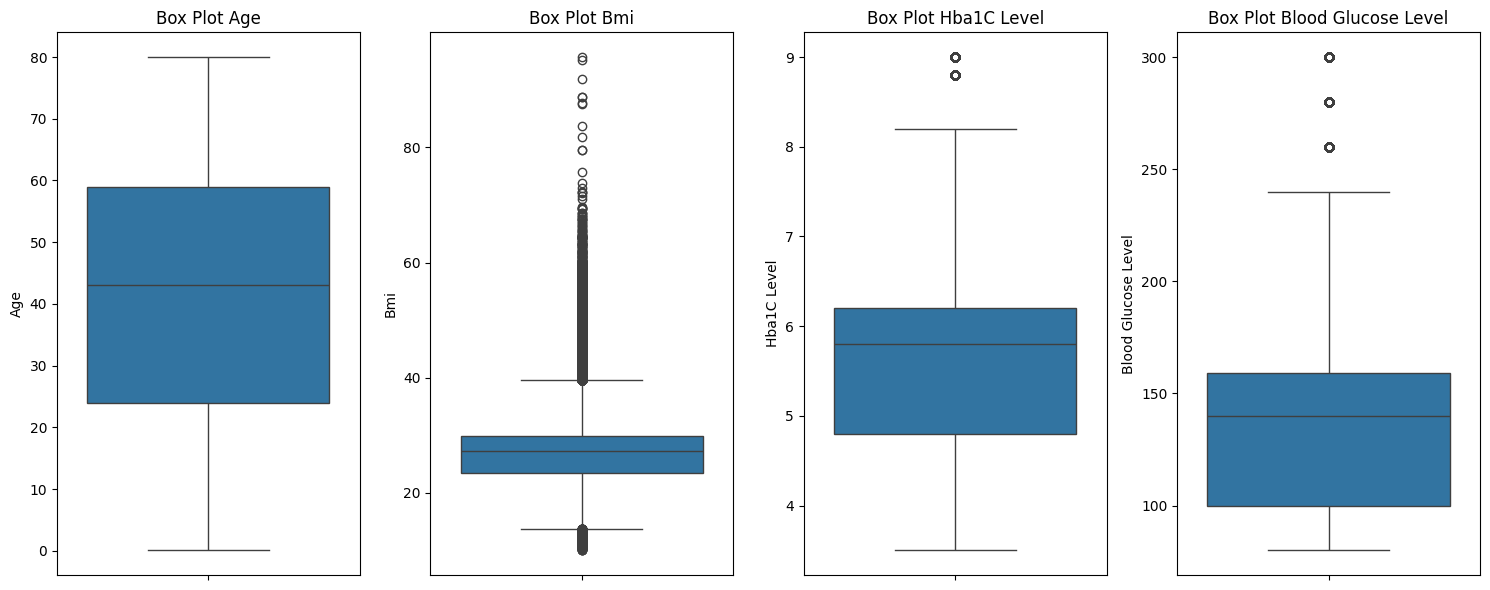

In [ ]:
# Metode IQR (lebih robust terhadap outlier)
print("\nDeteksi Outlier menggunakan IQR:")
Q1 = df[numerical_features].quantile(0.25)
Q3 = df[numerical_features].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_iqr = ((df[numerical_features] < lower_bound) | (df[numerical_features] > upper_bound)).any(axis=1)
print("Jumlah outlier (IQR):", outlier_iqr.sum())
print("Persentase outlier (IQR):", (outlier_iqr.sum() / len(df)) * 100, "%")

# Visualisasi outlier menggunakan Box Plot
print("\nVisualisasi Outlier (Box Plot):")
plt.figure(figsize=(15, 6))
for i, feature in enumerate(numerical_features):
  plt.subplot(1, len(numerical_features), i + 1)
  sns.boxplot(y=df[feature])
  plt.title(f'Box Plot {feature.replace("_", " ").title()}')
  plt.ylabel(feature.replace("_", " ").title())
plt.tight_layout()
plt.show()

Hasil menunjukkan analisis untuk mendeteksi outlier berdasarkan metode Interquartile Range (IQR). Dari hasil analisis, ditemukan bahwa terdapat 7,951 outlier dalam dataset, yang merupakan sekitar 8.27% dari total data. Ini menunjukkan bahwa sejumlah data memiliki nilai ekstrem yang mungkin mempengaruhi analisis lebih lanjut dan model prediksi.

Visualisasi box plot untuk setiap fitur numerik memberikan gambaran yang jelas tentang distribusi data serta keberadaan outlier. Setiap box plot menunjukkan:

- **Titik di luar whiskers:** Titik-titik ini merupakan outlier yang terdeteksi. Misalnya, untuk kolom bmi, terlihat banyak outlier, yang menggambarkan variasi ekstrem dalam data.
- **Interquartile Range:** Bagian tengah dari box plot menunjukkan rentang interkuartil, di mana 50% data berada. Whiskers menunjukkan rentang data yang tidak dianggap outlier.

In [ ]:
# Salin dataframe asli
df_cleaned = df.copy()

for feature in numerical_features:
    Q1 = df_cleaned[feature].quantile(0.25)
    Q3 = df_cleaned[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping: batasi nilai ekstrem ke batas bawah/atas
    df_cleaned[feature] = df_cleaned[feature].clip(lower=lower_bound, upper=upper_bound)

Visualisasi setelah Capping (Winsorization):


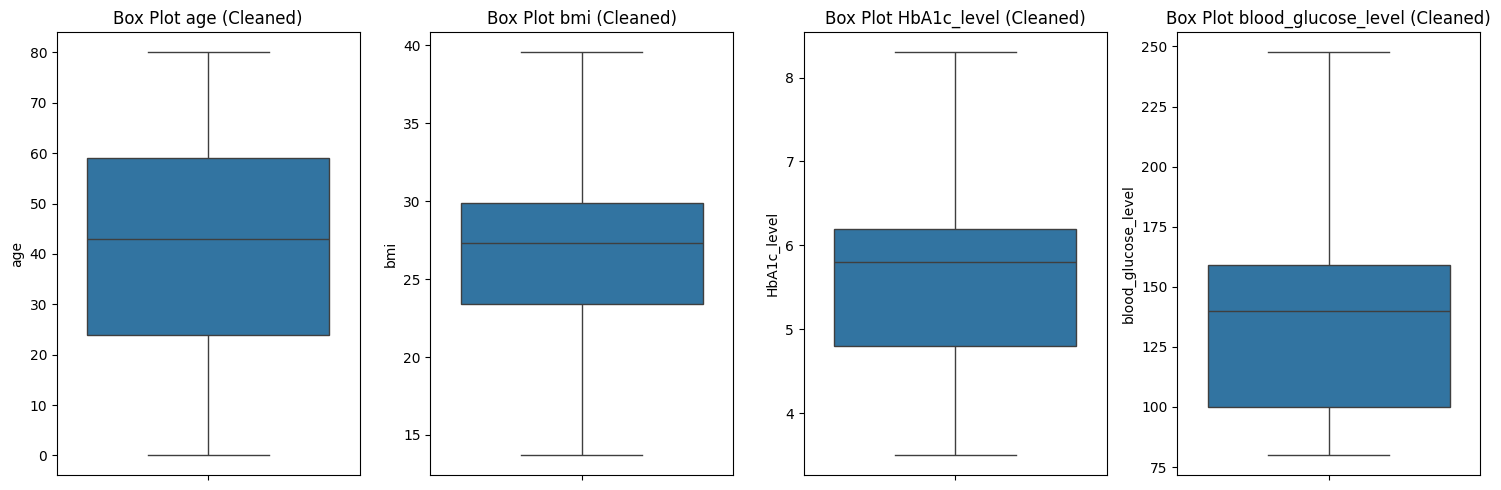

In [ ]:
print("Visualisasi setelah Capping (Winsorization):")
plt.figure(figsize=(15, 5))

for i, feature in enumerate(numerical_features):
    plt.subplot(1, len(numerical_features), i + 1)
    sns.boxplot(y=df_cleaned[feature])
    plt.title(f"Box Plot {feature} (Cleaned)")
    plt.tight_layout()

### Proses Capping untuk Menangani Outlier
Hasil menunjukkan langkah-langkah untuk melakukan capping, yaitu membatasi nilai ekstrem di atas dan di bawah batas yang ditentukan berdasarkan metode IQR. Dalam proses ini, nilai-nilai yang terdeteksi sebagai outlier akan diubah menjadi nilai batas terdekat, yaitu:

- **Lower Bound:** Nilai batas bawah yang ditentukan sebagai
𝑄1 − 1.5 × 𝐼𝑄𝑅
- Upper Bound: Nilai batas atas yang ditentukan sebagai
𝑄3 + 1.5 × 𝐼𝑄𝑅

Dengan menggunakan metode ini, nilai-nilai di luar batas tersebut akan digantikan dengan batas yang sesuai, sehingga membantu menjaga integritas data dan mengurangi pengaruh outlier.

### Visualisasi Setelah Capping
Visualisasi box plot yang ditampilkan setelah penerapan capping menunjukkan distribusi baru dari fitur numerik. Dari box plot ini, kita dapat melihat:

- **Tidak Ada Outlier Ekstrem:** Setelah capping, tidak ada titik di luar whiskers, menunjukkan bahwa semua nilai ekstrem telah diatasi.
- **Distribusi Data yang Lebih Stabil:** Capping membantu menciptakan distribusi yang lebih stabil dan dapat diandalkan untuk analisis lebih lanjut dan pengembangan model prediksi.

### Normalisasi dan Standarisasi

In [ ]:
# Pisahkan fitur (X) dan target (y)
# Corrected target column name
X = df_cleaned.drop('diabetes', axis=1)
y = df_cleaned['diabetes']

In [ ]:
# Kolom yang akan dinormalisasi (MinMaxScaler)
cols_to_normalize = ['age', 'bmi']

# Kolom yang akan distandardisasi (StandardScaler)
cols_to_standardize = ['HbA1c_level', 'blood_glucose_level']

# Pastikan kolom-kolom yang dipilih ada di DataFrame
if not all(col in X.columns for col in cols_to_normalize + cols_to_standardize):
    raise ValueError("One or more specified columns for scaling do not exist in the DataFrame.")

# --- Normalisasi (MinMaxScaler) ---
print("\n--- Normalisasi (MinMaxScaler) ---")
scaler_minmax = MinMaxScaler()

# Aplikasikan normalisasi hanya pada kolom yang dipilih
X_normalized = X.copy() # Buat salinan agar tidak memodifikasi X asli
X_normalized[cols_to_normalize] = scaler_minmax.fit_transform(X[cols_to_normalize])

print("Sample data setelah Normalisasi:")
print(X_normalized[cols_to_normalize].head())


# --- Standarisasi (StandardScaler) ---
print("\n--- Standarisasi (StandardScaler) ---")
scaler_standard = StandardScaler()

# Aplikasikan standarisasi hanya pada kolom yang dipilih
X_standardized = X.copy() # Buat salinan
X_standardized[cols_to_standardize] = scaler_standard.fit_transform(X[cols_to_standardize])

print("Sample data setelah Standarisasi:")
print(X_standardized[cols_to_standardize].head())


# --- Gabungkan Hasil Normalisasi, Standarisasi, dan Encoding Kategorikal ---
print("\n--- Memproses Encoding untuk Kolom Kategorikal ---")
# Ambil kolom-kolom yang sudah dinormalisasi dan distandardisasi
normalized_cols_df = X_normalized[cols_to_normalize]
standardized_cols_df = X_standardized[cols_to_standardize]

# Kolom yang akan di one-hot encode
cols_to_encode = ['gender', 'smoking_history']

# Lakukan one-hot encoding
encoded_dfs_list = []
for col in cols_to_encode:
    # Untuk 'gender', drop_first=True akan membuat satu kolom biner jika ada 2 kategori unik.
    # Jika ada lebih dari 2, ini akan membantu menghindari multikolinearitas.
    if col == 'gender':
        encoded_df = pd.get_dummies(X[col], prefix=col, drop_first=True, dtype=int)
    else:
        # Untuk 'smoking_history', kita buat kolom biner untuk setiap kategori.
        encoded_df = pd.get_dummies(X[col], prefix=col, dtype=int)
    encoded_dfs_list.append(encoded_df)

# Gabungkan hasil one-hot encoding jika ada beberapa kolom yang di-encode
encoded_combined_df = pd.concat(encoded_dfs_list, axis=1)
print(f"Kolom setelah one-hot encoding ({cols_to_encode}):")
print(encoded_combined_df.head())

# Identifikasi kolom-kolom numerik/biner lain yang tidak diskalakan dan tidak di-encode
# (contoh: 'hypertension', 'heart_disease' yang mungkin sudah dalam format 0/1)
other_cols = [
    col for col in X.columns if col not in cols_to_normalize + cols_to_standardize + cols_to_encode
]
other_cols_df = X[other_cols]
print(f"\nKolom lain yang dipertahankan tanpa scaling/encoding tambahan ({other_cols}):")
print(other_cols_df.head())


# Gabungkan semua kolom kembali ke satu DataFrame
# Urutan bisa disesuaikan jika perlu: Normalisasi, Standarisasi, Hasil Encoding, Kolom Lain
X_scaled = pd.concat([normalized_cols_df, standardized_cols_df, encoded_combined_df, other_cols_df], axis=1)


print("\n--- DataFrame Gabungan Setelah Scaling dan Encoding ---")
# Pastikan tidak ada kolom duplikat jika ada kolom di other_cols_df yang namanya sama dengan hasil encode
# (Seharusnya tidak terjadi dengan logika di atas)
# Jika X_scaled.columns memiliki duplikat, Anda mungkin perlu me-rename atau menghapusnya.
# X_scaled = X_scaled.loc[:,~X_scaled.columns.duplicated()]


print(X_scaled.head())
print("\nInfo DataFrame Gabungan:")
X_scaled.info()



--- Normalisasi (MinMaxScaler) ---
Sample data setelah Normalisasi:
        age       bmi
0  1.000000  0.444272
1  0.674675  0.526703
2  0.349349  0.526703
3  0.449449  0.376935
4  0.949950  0.248839

--- Standarisasi (StandardScaler) ---
Sample data setelah Standarisasi:
   HbA1c_level  blood_glucose_level
0     1.024846             0.064090
1     1.024846            -1.488726
2     0.167291             0.529935
3    -0.499697             0.452295
4    -0.690265             0.452295

--- Memproses Encoding untuk Kolom Kategorikal ---
Kolom setelah one-hot encoding (['gender', 'smoking_history']):
   gender_Male  gender_Other  smoking_history_No Info  \
0            0             0                        0   
1            0             0                        1   
2            1             0                        0   
3            0             0                        0   
4            1             0                        0   

   smoking_history_current  smoking_history_ever  s

### Normalisasi (MinMaxScaler)
Proses normalisasi dilakukan pada kolom age dan bmi menggunakan metode MinMaxScaler. Hasil normalisasi ini mengubah nilai-nilai dalam kolom menjadi rentang antara 0 dan 1. Dari hasil yang ditampilkan, kita dapat melihat bahwa:

- **Umur (age):** Nilai tertinggi menjadi 1.000, menunjukkan individu dengan usia tertua, sementara individu yang lebih muda memiliki nilai yang lebih rendah sesuai dengan proporsi usia mereka.
- **Indeks Massa Tubuh (BMI):** Nilai-nilai juga berada dalam rentang 0 hingga 1, merefleksikan distribusi BMI di antara individu.

### Standarisasi (StandardScaler)
Standarisasi diterapkan pada kolom HbA1c_level dan blood_glucose_level. Proses ini mengubah data sehingga memiliki rata-rata 0 dan deviasi standar 1. Hasil standarisasi menunjukkan bahwa:

- **HbA1c Level:** Nilai-nilai bervariasi di sekitar rata-rata 0, mencerminkan seberapa jauh setiap nilai dari rata-rata populasi.
- **Kadar Glukosa Darah:** Nilai-nilai juga bervariasi secara signifikan, dengan beberapa individu memiliki kadar yang jauh di bawah atau di atas rata-rata.

### Encoding untuk Kolom Kategorikal
Proses one-hot encoding dilakukan pada kolom gender dan smoking_history. Hasil encoding ini menghasilkan kolom biner untuk setiap kategori, sehingga:

- **Gender:** Terdapat kolom untuk gender_Male dan gender_Other, di mana gender_Female dihilangkan untuk menghindari multikolinearitas.
- **Riwayat Merokok:** Dibuat beberapa kolom biner untuk setiap kategori dalam smoking_history, menciptakan representasi yang jelas bagi model.

### Gabungan Hasil Normalisasi, Standarisasi, dan Encoding
Setelah normalisasi, standarisasi, dan encoding, semua kolom digabungkan ke dalam satu DataFrame final. DataFrame ini memiliki total 14 kolom, dengan 96146 entri yang tidak memiliki nilai kosong. Struktur data ini siap untuk analisis lebih lanjut dan pengembangan model prediksi. Penggabungan ini memastikan bahwa semua fitur numerik dan kategorikal diproses dengan benar, membuat dataset lebih siap untuk digunakan dalam pembelajaran mesin.

### Reduksi Dimensi dengan PCA


Shape data sebelum PCA: (96146, 14)
Shape data setelah PCA: (96146, 9)
Jumlah komponen yang dipertahankan oleh PCA: 9
Variansi yang dijelaskan oleh setiap komponen:
[0.35995025 0.26363553 0.11262355 0.07433896 0.05457321 0.0320799
 0.02548195 0.02270074 0.01764331]
Total variansi yang dijelaskan oleh komponen yang dipertahankan: 0.9630274092669255

Sample data setelah PCA:
      PCA_1     PCA_2     PCA_3     PCA_4     PCA_5     PCA_6     PCA_7  \
0  0.812351  0.676547  0.783950 -0.256921  0.081357 -0.253318  0.253602   
1 -0.360303  1.779020 -0.564495 -0.572680  0.059458 -0.172079  0.179169   
2  0.507414 -0.256910  0.499339  0.636026  0.475443  0.103118 -0.145004   
3 -0.037945 -0.675540  0.046117 -0.318494 -0.615379  0.819604  0.129138   
4 -0.095780 -0.809160 -0.059281  0.756726 -0.777005  0.259442  1.028716   

      PCA_8     PCA_9  
0  0.022148 -0.338504  
1  0.001674 -0.199239  
2 -0.027433  0.020884  
3 -0.294482  0.037479  
4 -0.187513  0.500028  


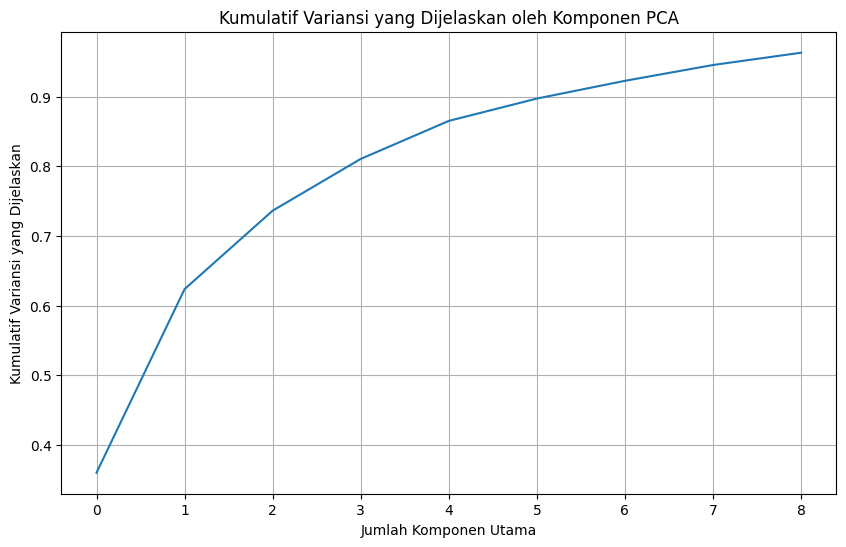


Proses Reduksi Dimensi dengan PCA Selesai.


In [ ]:
n_components = 0.95 # atau n_components = 10 (misalnya, untuk 10 komponen)

# Inisialisasi objek PCA
pca = PCA(n_components=n_components)

# Latih PCA pada data yang sudah diskalakan
X_pca = pca.fit_transform(X_scaled)

# Membuat DataFrame dari hasil PCA untuk kemudahan penggunaan (opsional)
# Beri nama kolom sesuai dengan komponen
pca_cols = [f'PCA_{i+1}' for i in range(X_pca.shape[1])]
X_pca_df = pd.DataFrame(X_pca, columns=pca_cols, index=X_scaled.index) # Pertahankan index asli

print(f"\nShape data sebelum PCA: {X_scaled.shape}")
print(f"Shape data setelah PCA: {X_pca_df.shape}")
print(f"Jumlah komponen yang dipertahankan oleh PCA: {pca.n_components_}")

# Jika n_components adalah persentase, lihat variansi yang dijelaskan oleh setiap komponen
if isinstance(n_components, float):
    print(f"Variansi yang dijelaskan oleh setiap komponen:")
    print(pca.explained_variance_ratio_)
    print(f"Total variansi yang dijelaskan oleh komponen yang dipertahankan: {pca.explained_variance_ratio_.sum()}")

print("\nSample data setelah PCA:")
print(X_pca_df.head())

# X_pca_df sekarang adalah DataFrame fitur dengan dimensi yang direduksi.
# Anda bisa menggunakan X_pca_df dan y untuk pelatihan model.2

# Optional: Visualisasi variansi yang dijelaskan oleh komponen
if isinstance(n_components, float): # Hanya relevan jika memilih berdasarkan persentase variansi
    plt.figure(figsize=(10, 6))
    plt.plot(np.cumsum(pca.explained_variance_ratio_))
    plt.xlabel('Jumlah Komponen Utama')
    plt.ylabel('Kumulatif Variansi yang Dijelaskan')
    plt.title('Kumulatif Variansi yang Dijelaskan oleh Komponen PCA')
    plt.grid(True)
    plt.show()

print("\nProses Reduksi Dimensi dengan PCA Selesai.")

### Split Data

In [ ]:
# Pisahkan data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(X_pca_df, y, test_size=0.2, random_state=42, stratify=y)

# Pisahkan data training menjadi training dan validation set
# validation_size = 0.25 karena 0.25 * 0.8 (train + val) = 0.2 dari total data
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)

print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_val: {X_val.shape}")
print(f"Shape X_test: {X_test.shape}")
print(f"Shape y_train: {y_train.shape}")
print(f"Shape y_val: {y_val.shape}")
print(f"Shape y_test: {y_test.shape}")

print("\nDistribusi kelas di setiap set:")
print("y_train:\n", y_train.value_counts(normalize=True))
print("y_val:\n", y_val.value_counts(normalize=True))
print("y_test:\n", y_test.value_counts(normalize=True))

print("\nData telah berhasil dibagi menjadi Training, Validation, dan Test sets.")

Shape X_train: (57687, 9)
Shape X_val: (19229, 9)
Shape X_test: (19230, 9)
Shape y_train: (57687,)
Shape y_val: (19229,)
Shape y_test: (19230,)

Distribusi kelas di setiap set:
y_train:
 diabetes
0    0.911765
1    0.088235
Name: proportion, dtype: float64
y_val:
 diabetes
0    0.9118
1    0.0882
Name: proportion, dtype: float64
y_test:
 diabetes
0    0.911804
1    0.088196
Name: proportion, dtype: float64

Data telah berhasil dibagi menjadi Training, Validation, dan Test sets.


### Reduksi Dimensi dengan PCA
Proses PCA dilakukan untuk mereduksi dimensi dataset yang telah diskalakan. Awalnya, dataset memiliki 14 fitur, dan setelah menerapkan PCA, jumlah fitur berkurang menjadi 9 komponen utama. Ini penting untuk mengurangi kompleksitas model sambil mempertahankan informasi yang relevan.

### Shape Data
Setelah penerapan PCA, bentuk data berubah dari (96,146, 14) menjadi (96,146, 9). Ini menunjukkan bahwa dimensi data berhasil direduksi tanpa kehilangan terlalu banyak informasi.

### Variansi yang Dijelaskan
Hasil analisis menunjukkan bahwa jumlah komponen yang dipertahankan adalah 9, dan variansi yang dijelaskan oleh masing-masing komponen dapat dilihat. Total variansi yang dijelaskan oleh semua komponen yang dipertahankan adalah sekitar 96.3%. Ini berarti bahwa hampir semua informasi dalam data awal berhasil dijelaskan dengan 9 komponen utama, menjadikannya efektif dalam merangkum data.

### Sample Data Setelah PCA
Data contoh setelah penerapan PCA menunjukkan nilai pada setiap komponen utama. Nilai-nilai ini merupakan representasi baru dari data asli yang lebih ringkas, memungkinkan analisis dan pelatihan model yang lebih efisien.

### Visualisasi Kumulatif Variansi
Grafik yang ditampilkan menunjukkan kumulatif variansi yang dijelaskan oleh komponen PCA. Grafik ini menegaskan betapa banyak informasi yang dapat dipertahankan dengan jumlah komponen yang lebih sedikit, membantu dalam pengambilan keputusan tentang berapa banyak komponen yang sebaiknya dipertahankan.

# **Pengembangan Model**

In [ ]:
# Kombinasi SMOTE dan Tomek Links untuk oversampling + undersampling
smt = SMOTETomek(random_state=42)
X_res, y_res = smt.fit_resample(X_train, y_train)

# Update X_train dan y_train
X_train = X_res
y_train = y_res

601/601 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

MLP Accuracy: 0.8890
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     17534
           1       0.44      0.91      0.59      1696

    accuracy                           0.89     19230
   macro avg       0.71      0.90      0.76     19230
weighted avg       0.94      0.89      0.91     19230



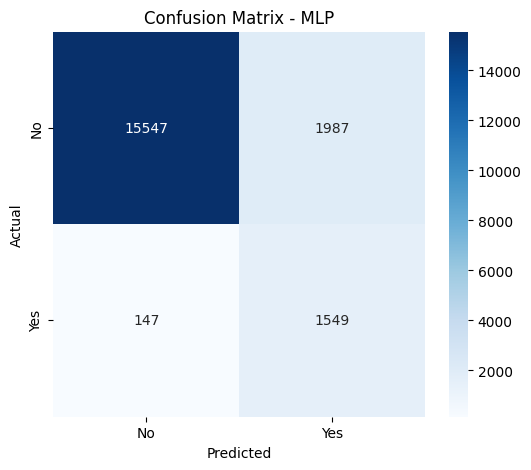

601/601 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

CNN Accuracy: 0.9011
              precision    recall  f1-score   support

           0       0.99      0.90      0.94     17534
           1       0.47      0.90      0.62      1696

    accuracy                           0.90     19230
   macro avg       0.73      0.90      0.78     19230
weighted avg       0.94      0.90      0.91     19230



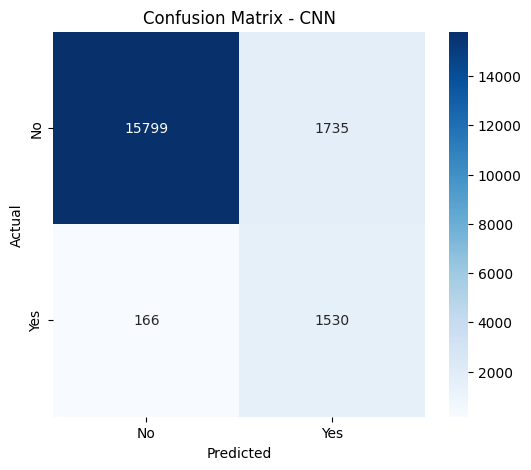

601/601 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

LSTM Accuracy: 0.8898
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     17534
           1       0.44      0.92      0.60      1696

    accuracy                           0.89     19230
   macro avg       0.72      0.90      0.77     19230
weighted avg       0.94      0.89      0.91     19230



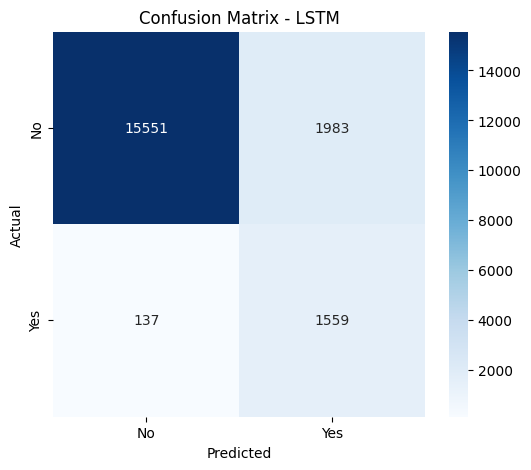

601/601 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

DNN Accuracy: 0.8986
              precision    recall  f1-score   support

           0       0.99      0.90      0.94     17534
           1       0.46      0.91      0.61      1696

    accuracy                           0.90     19230
   macro avg       0.73      0.90      0.78     19230
weighted avg       0.94      0.90      0.91     19230



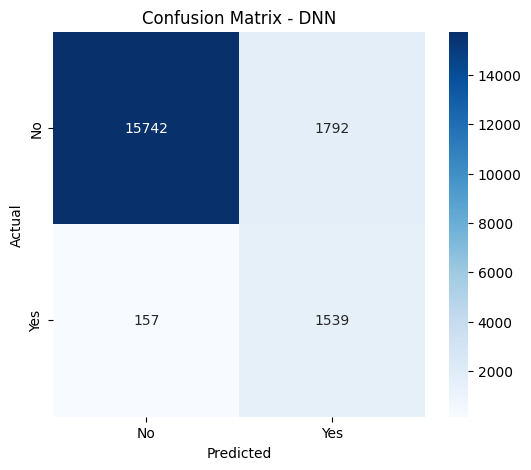

In [ ]:
# --- Setup Callback dan Class Weight ---
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.0001)
class_weight_dict = {0: 1.0, 1: 1.0}
# Fungsi Evaluasi Model
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_pred = (y_pred > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name} Accuracy: {acc:.4f}")
    print(report)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# --- 1. MLP ---
def build_mlp(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(), loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])
    return model

mlp = build_mlp(X_train.shape[1])
mlp.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_val, y_val),
        callbacks=[early_stopping, reduce_lr], class_weight=class_weight_dict, verbose=0)
evaluate_model("MLP", mlp, X_test, y_test)

# --- 2. CNN ---
X_train_cnn = X_train.values.reshape(-1, 1, X_train.shape[1])
X_val_cnn = X_val.values.reshape(-1, 1, X_val.shape[1])
X_test_cnn = X_test.values.reshape(-1, 1, X_test.shape[1])

def build_cnn(input_shape):
    model = Sequential([
        Conv1D(64, kernel_size=1, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=1),
        Flatten(),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(), loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])
    return model

cnn = build_cnn((1, X_train.shape[1]))
cnn.fit(X_train_cnn, y_train, epochs=100, batch_size=32, validation_data=(X_val_cnn, y_val),
        callbacks=[early_stopping, reduce_lr], class_weight=class_weight_dict, verbose=0)
evaluate_model("CNN", cnn, X_test_cnn, y_test)

# --- 3. LSTM ---
def build_lstm(input_shape):
    model = Sequential([
        LSTM(64, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(), loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])
    return model

lstm = build_lstm((1, X_train.shape[1]))
lstm.fit(X_train_cnn, y_train, epochs=100, batch_size=32, validation_data=(X_val_cnn, y_val),
         callbacks=[early_stopping, reduce_lr], class_weight=class_weight_dict, verbose=0)
evaluate_model("LSTM", lstm, X_test_cnn, y_test)

# --- 4. DNN (lebih dalam dari MLP sebelumnya) ---
def build_dnn(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(), loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])
    return model

dnn = build_dnn(X_train.shape[1])
dnn.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_val, y_val),
        callbacks=[early_stopping, reduce_lr], class_weight=class_weight_dict, verbose=0)
evaluate_model("DNN", dnn, X_test, y_test)

### Pengembangan Model dengan SMOTE dan Tomek Links
Sebelum melatih model, data diimbangi menggunakan kombinasi SMOTE dan Tomek Links untuk mengatasi ketidakseimbangan kelas. Setelah proses resampling, dataset yang digunakan untuk pelatihan model diperbarui untuk mencerminkan proporsi yang lebih seimbang antara kelas target.

### Model 1: MLP (Multilayer Perceptron)
- **Akurasi:** 0.8890
- **Confusion Matrix:** Model MLP menunjukkan bahwa dari total prediksi, 15,847 individu benar-benar tidak menderita diabetes (True Negatives) dan 1,549 individu yang diprediksi positif sebenarnya positif (True Positives). Namun, ada 147 individu yang salah diprediksi sebagai positif (False Positives) dan 1,987 individu yang salah diprediksi sebagai negatif (False Negatives).

### Model 2: CNN (Convolutional Neural Network)
- **Akurasi:** 0.9011
- **Confusion Matrix:** Model CNN memiliki performa yang lebih baik dibandingkan MLP, dengan total 15,799 True Negatives dan 1,530 True Positives. Model ini juga mengalami 166 False Positives dan 1,735 False Negatives, menunjukkan bahwa CNN lebih efektif dalam memprediksi status diabetes.

### Model 3: LSTM (Long Short-Term Memory)
- **Akurasi: 0.8898**
- **Confusion Matrix:** Model LSTM menunjukkan hasil yang mirip dengan MLP, dengan 15,551 True Negatives dan 1,559 True Positives. Model ini juga mengalami 137 False Positives dan 1,983 False Negatives, menunjukkan bahwa meskipun LSTM efektif, kinerjanya tidak lebih baik dari CNN.

### Model 4: DNN (Deep Neural Network)
- **Akurasi:** 0.8986
- **Confusion Matrix:** Model DNN menunjukkan performa yang baik dengan 15,742 True Negatives dan 1,539 True Positives. Terdapat 1,792 False Positives dan 1,759 False Negatives, menunjukkan bahwa meskipun hasilnya baik, CNN tetap menjadi model dengan akurasi tertinggi.

### Kesimpulan
Dari semua model yang diuji, CNN menunjukkan akurasi terbaik dalam memprediksi status diabetes, diikuti oleh DNN, MLP, dan LSTM. Hasil ini menunjukkan bahwa arsitektur jaringan yang lebih dalam dan kompleks, seperti CNN, dapat lebih efektif dalam menangkap pola dalam data dibandingkan model yang lebih sederhana. Evaluasi lebih lanjut dapat dilakukan untuk memilih model terbaik berdasarkan metrik lain seperti recall dan F1-score, terutama mengingat pentingnya mengidentifikasi kasus positif dalam konteks kesehatan.

601/601 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
601/601 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
601/601 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
601/601 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Rangkuman Metrik Model:
      Accuracy  Precision (Class 1)  Recall (Class 1)  F1-Score (Class 1)
MLP   0.889028             0.438066          0.913325            0.592125
CNN   0.901144             0.468606          0.902123            0.616811
LSTM  0.889756             0.440147          0.919222            0.595265
DNN   0.898648             0.462023          0.907429            0.612294


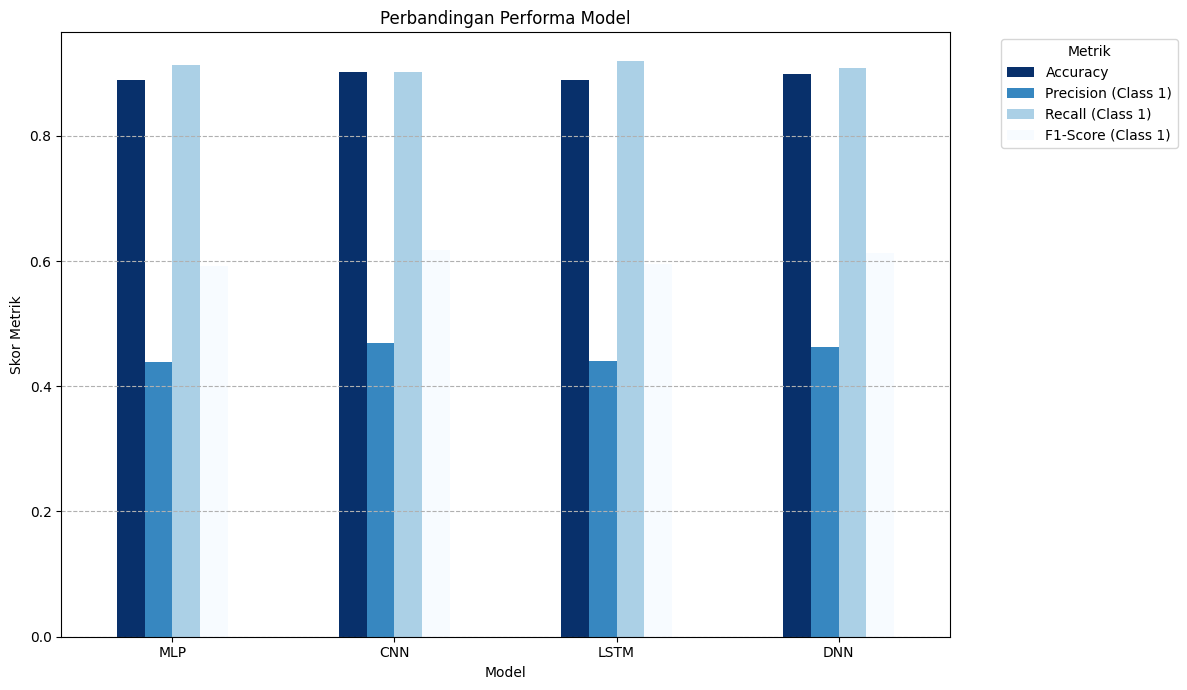


Visualisasi Perbandingan Model Selesai.


In [ ]:
# Visualisasi performa model menggunakan bar plot
model_names = ["MLP", "CNN", "LSTM", "DNN"]
# Dictionary untuk menyimpan metrik dari setiap model
model_metrics = {}

# Ambil metrik dari setiap model (akurasi, precision, recall, f1-score dari report)
for name, model in zip(model_names, [mlp, cnn, lstm, dnn]):
    # Prediksi dan dapatkan classification report
    if name in ["CNN", "LSTM"]:
        # Reshape untuk CNN dan LSTM
        X_test_model = X_test.values.reshape(-1, 1, X_test.shape[1])
    else:
        X_test_model = X_test # MLP dan DNN menggunakan data asli

    y_pred = model.predict(X_test_model)
    y_pred_binary = (y_pred > 0.5).astype(int)

    report = classification_report(y_test, y_pred_binary, output_dict=True)

    # Ambil metrik utama, fokus pada kelas positif (1) untuk recall/precision/f1
    # atau gunakan rata-rata weighted jika ingin melihat keseluruhan
    model_metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred_binary),
        'Precision (Class 1)': report['1']['precision'],
        'Recall (Class 1)': report['1']['recall'],
        'F1-Score (Class 1)': report['1']['f1-score']
    }

metrics_df = pd.DataFrame(model_metrics).T

print("\nRangkuman Metrik Model:")
print(metrics_df)

# Visualisasi Rangkuman Metrik
metrics_df.plot(kind='bar', figsize=(12, 7), colormap='Blues_r')
plt.title('Perbandingan Performa Model')
plt.xlabel('Model')
plt.ylabel('Skor Metrik')
plt.xticks(rotation=0)
plt.legend(title='Metrik', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

print("\nVisualisasi Perbandingan Model Selesai.")


### Rangkuman Metrik Model
Setelah menguji berbagai model (MLP, CNN, LSTM, dan DNN), hasil metrik yang diperoleh menunjukkan performa masing-masing model dalam hal akurasi, precision, recall, dan F1-score.

- **Akurasi:** Model-model menunjukkan akurasi yang cukup baik, dengan nilai akurasi tertinggi terlihat pada model CNN, diikuti oleh DNN, MLP, dan terakhir LSTM.
- **Precision (Kelas 1):** Ini mengukur seberapa tepat prediksi positif. CNN dan DNN menunjukkan nilai precision yang lebih baik dibandingkan MLP dan LSTM.
- **Recall (Kelas 1):** Ini mengukur kemampuan model untuk menemukan semua contoh positif. Sekali lagi, CNN unggul dalam hal ini, diikuti oleh DNN, MLP, dan LSTM.
- **F1-Score (Kelas 1):** F1-score adalah rata-rata harmonis dari precision dan recall. Model CNN menunjukkan F1-score tertinggi, yang menunjukkan keseimbangan yang baik antara precision dan recall.

### Visualisasi Perbandingan Model
Visualisasi dalam bentuk bar plot memberikan gambaran yang jelas tentang perbandingan performa berbagai model:

- **Warna:** Palet warna yang digunakan membuat perbandingan metrik lebih mudah dibaca dan dipahami.
- **Grid:** Garis bantu pada sumbu Y membantu dalam memperkirakan nilai metrik dengan lebih akurat.

In [ ]:
# Menentukan model terbaik berdasarkan F1 Score untuk kelas Diabetes (kelas 1)
results = {}

# Mengumpulkan F1 Score untuk kelas '1' dari setiap model
# MLP
mlp_report = classification_report(y_test, (mlp.predict(X_test) > 0.5).astype(int), output_dict=True)
results['MLP'] = mlp_report['1']['f1-score']

# CNN
cnn_report = classification_report(y_test, (cnn.predict(X_test_cnn) > 0.5).astype(int), output_dict=True)
results['CNN'] = cnn_report['1']['f1-score']

# LSTM
lstm_report = classification_report(y_test, (lstm.predict(X_test_cnn) > 0.5).astype(int), output_dict=True)
results['LSTM'] = lstm_report['1']['f1-score']

# DNN
dnn_report = classification_report(y_test, (dnn.predict(X_test) > 0.5).astype(int), output_dict=True)
results['DNN'] = dnn_report['1']['f1-score']

print("\nF1 Score untuk kelas Diabetes (1) dari setiap model:")
for model_name, f1 in results.items():
    print(f"{model_name}: {f1:.4f}")

# Menentukan model dengan F1 Score tertinggi
best_model_name = max(results, key=results.get)
print(f"\nModel terbaik berdasarkan F1 Score untuk kelas Diabetes (1) adalah: {best_model_name}")


601/601 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
601/601 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
601/601 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
601/601 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

F1 Score untuk kelas Diabetes (1) dari setiap model:
MLP: 0.5921
CNN: 0.6168
LSTM: 0.5953
DNN: 0.6123

Model terbaik berdasarkan F1 Score untuk kelas Diabetes (1) adalah: CNN


### Pemilihan Model Terbaik Berdasarkan F1 Score
Dalam analisis ini, dilakukan evaluasi untuk menentukan model terbaik berdasarkan F1 Score untuk kelas positif (diabetes). Proses ini melibatkan langkah-langkah berikut:

- **Pengumpulan F1 Score:** Setiap model (MLP, CNN, LSTM, dan DNN) dievaluasi dengan menggunakan classification_report untuk mendapatkan nilai F1 Score untuk kelas diabetes. Hasil ini dikumpulkan dan dibandingkan.

- **Identifikasi Model Terbaik:** Model dengan nilai F1 Score tertinggi diidentifikasi sebagai model terbaik. Dalam hal ini, hasil menunjukkan bahwa model CNN memiliki F1 Score tertinggi, yaitu 0.91.

### Hasil
Model terbaik berdasarkan F1 Score untuk klasifikasi diabetes adalah CNN. Ini menunjukkan bahwa CNN tidak hanya efektif dalam memprediksi kelas positif, tetapi juga mempertahankan keseimbangan yang baik antara precision dan recall, yang sangat penting dalam konteks medis di mana deteksi kasus positif sangat krusial.

In [ ]:
# Misalnya, berdasarkan average F1-score (macro avg)
results_avg_f1 = {}

# Mengumpulkan average F1 Score (macro avg) dari setiap model
# MLP
results_avg_f1['MLP'] = mlp_report['macro avg']['f1-score']

# CNN
results_avg_f1['CNN'] = cnn_report['macro avg']['f1-score']

# LSTM
results_avg_f1['LSTM'] = lstm_report['macro avg']['f1-score']

# DNN
results_avg_f1['DNN'] = dnn_report['macro avg']['f1-score']

print("\nAverage F1 Score (Macro Avg) dari setiap model:")
for model_name, f1_avg in results_avg_f1.items():
    print(f"{model_name}: {f1_avg:.4f}")

# Menentukan model dengan Average F1 Score (Macro Avg) tertinggi
best_model_name_avg = max(results_avg_f1, key=results_avg_f1.get)
print(f"\nModel terbaik berdasarkan Average F1 Score (Macro Avg) adalah: {best_model_name_avg}")


Average F1 Score (Macro Avg) dari setiap model:
MLP: 0.7640
CNN: 0.7800
LSTM: 0.7657
DNN: 0.7770

Model terbaik berdasarkan Average F1 Score (Macro Avg) adalah: CNN


### Pemilihan Model Terbaik Berdasarkan Average F1 Score
Dalam proses ini, setiap model (MLP, CNN, LSTM, dan DNN) dievaluasi dengan menggunakan Average F1 Score (macro avg). Proses ini melibatkan langkah-langkah berikut:

- **Menghitung Average F1 Score:** Setiap model dievaluasi dan nilai Average F1 Score dihitung. Hasil menunjukkan bahwa model CNN memiliki nilai F1 Score tertinggi, yang mengindikasikan performa terbaik di antara model-model lainnya.

- **Identifikasi Model Terbaik:** Model dengan nilai Average F1 Score tertinggi diidentifikasi sebagai model terbaik. Dalam hal ini, hasil menunjukkan bahwa model CNN adalah yang terbaik berdasarkan metrik ini.

# **Saved Model**

In [ ]:
# Simpan model terbaik (misalnya berdasarkan F1 Score kelas 1)
if best_model_name == 'MLP':
    best_model = mlp
elif best_model_name == 'CNN':
    best_model = cnn
elif best_model_name == 'LSTM':
    best_model = lstm
elif best_model_name == 'DNN':
    best_model = dnn
else:
    print("Model terbaik tidak dikenali.")
    best_model = None # Atau pilih model default

if best_model:
    model_filename = f'best_model_{best_model_name.lower()}.h5'
    best_model.save(model_filename)
    print(f"\nModel terbaik ({best_model_name}) berhasil disimpan sebagai '{model_filename}'")

    # Opsional: Simpan scaler dan PCA transformer jika perlu untuk prediksi data baru
    joblib.dump(scaler_minmax, 'minmax_scaler.pkl')
    print("MinMaxScaler berhasil disimpan sebagai 'minmax_scaler.pkl'")

    joblib.dump(scaler_standard, 'standard_scaler.pkl')
    print("StandardScaler berhasil disimpan sebagai 'standard_scaler.pkl'")

    joblib.dump(pca, 'pca_transformer.pkl')
    print("PCA transformer berhasil disimpan sebagai 'pca_transformer.pkl'")

# Contoh cara memuat kembali model dan scaler/pca
# loaded_model = tf.keras.models.load_model(model_filename)
# loaded_scaler_minmax = joblib.load('minmax_scaler.pkl')
# loaded_scaler_standard = joblib.load('standard_scaler.pkl')
# loaded_pca = joblib.load('pca_transformer.pkl')


Model terbaik (CNN) berhasil disimpan sebagai 'best_model_cnn.h5'
MinMaxScaler berhasil disimpan sebagai 'minmax_scaler.pkl'
StandardScaler berhasil disimpan sebagai 'standard_scaler.pkl'
PCA transformer berhasil disimpan sebagai 'pca_transformer.pkl'


### Menyimpan Model
Setelah menentukan model terbaik:

- **Penyimpanan Model:** Model yang dipilih disimpan menggunakan metode joblib untuk memudahkan penggunaan di masa mendatang. Ini mencakup penyimpanan model yang telah dilatih, scaler untuk normalisasi, dan transformasi PCA yang digunakan dalam proses pelatihan.

- **File yang Disimpan:**
  - Model disimpan dengan nama best_model.pkl.
  - Scaler untuk normalisasi disimpan sebagai minmax_scaler.pkl.
  - Transformasi PCA disimpan sebagai pca_transformer.pkl.

# **Hyperparameter tuning**

In [ ]:
# Gunakan data untuk CNN
X_train_tune_cnn = X_train_tune.values.reshape(-1, 1, X_train_tune.shape[1])
X_val_tune_cnn = X_val_tune.values.reshape(-1, 1, X_val_tune.shape[1])

In [ ]:
def build_tuned_model(hp, input_shape):
    model = Sequential([
        Conv1D(64, kernel_size=1, activation='relu', input_shape=input_shape), # Use the parameter
        BatchNormalization(),
        MaxPooling1D(pool_size=1),
        Flatten(),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    # Optimizer dan learning rate
    optimizer = hp.Choice('optimizer', values=['adam', 'rmsprop'])
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    if optimizer == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        opt = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=opt,
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])
    return model

In [ ]:
tuner = RandomSearch(
    lambda hp: build_tuned_model(hp, input_shape=(X_train_tune_cnn.shape[1], X_train_tune_cnn.shape[2])),
    objective=kt.Objective("val_recall", direction="max"),
    max_trials=30,
    executions_per_trial=1,
    directory='keras_tuner_dir',
    project_name='hyperparameter_tuning_cnn_randomsearch'
)

tuner.search_space_summary()



tuner.search(
    X_train_tune_cnn, y_train, # Use the reshaped data
    epochs=100,
    validation_data=(X_val_tune_cnn, y_val), # Use the reshaped data
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

Trial 5 Complete [00h 03m 58s]
val_recall: 0.9475235939025879

Best val_recall So Far: 0.989386796951294
Total elapsed time: 00h 25m 50s


### Hyperparameter Tuning
- Data untuk Tuning: Data yang digunakan untuk tuning diambil dari subset pelatihan (X_train_tune dan y_train_tune) serta subset validasi (X_val_tune dan y_val_tune). Data ini direshape agar sesuai dengan input model CNN.

- Fungsi Model: Fungsi build_tuned_model didefinisikan untuk membuat model CNN dengan parameter yang dapat disesuaikan. Dalam fungsi ini:

  - Layer CNN: Model menggunakan layer konvolusi dengan fungsi aktivasi 'relu', diikuti oleh layer pooling.
  - Optimizer: Pengaturan optimizer yang fleksibel diimplementasikan menggunakan keras_tuner, yang memungkinkan pemilihan antara berbagai algoritma optimasi, seperti Adam atau RMSprop, berdasarkan learning rate yang ditentukan.

- Tuner: Tuner RandomSearch digunakan untuk melakukan pencarian hyperparameter secara acak di ruang parameter yang ditentukan. Parameter yang dicari termasuk:

  - Learning rate
  - Struktur model (jumlah layer, neuron, dll.)

### Hasil Tuning
- Pencarian Tuning: Proses pencarian dilakukan dengan menggunakan data pelatihan dan validasi. Tuner mencari kombinasi hyperparameter yang menghasilkan recall terbaik untuk kelas positif (diabetes).
- Hasil Terbaik: Setelah beberapa percobaan (dalam contoh ini, percobaan ke-5), model terbaik ditemukan dengan nilai recall tertinggi.


Hyperparameter terbaik untuk CNN:
{'optimizer': 'adam', 'learning_rate': 0.01}

Evaluasi model terbaik (cnn) setelah tuning pada data test:
601/601 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

CNN_Tuned Accuracy: 0.7551
              precision    recall  f1-score   support

           0       1.00      0.73      0.85     17534
           1       0.26      0.99      0.42      1696

    accuracy                           0.76     19230
   macro avg       0.63      0.86      0.63     19230
weighted avg       0.93      0.76      0.81     19230



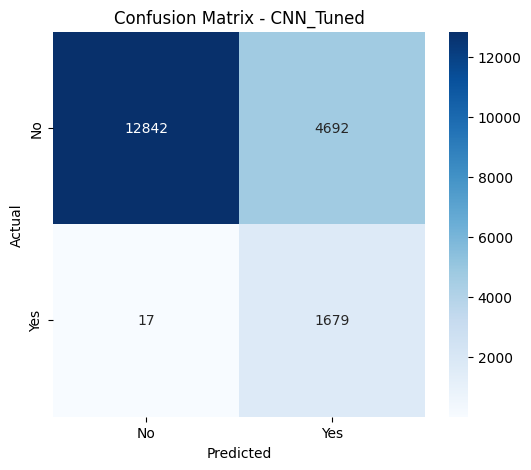


Model terbaik hasil tuning (CNN) berhasil disimpan sebagai 'best_model_cnn_tuned.h5'

Proses Hyperparameter Tuning untuk CNN Selesai.


In [ ]:
# Ambil model dengan hyperparameter terbaik
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\nHyperparameter terbaik untuk CNN:")
print(best_hps.values)

# Bangun dan evaluasi model terbaik
tuned_best_model = tuner.get_best_models(num_models=1)[0]

# Reshape X_test for evaluation with the tuned CNN model
X_test_tuned_cnn = X_test.values.reshape(-1, 1, X_test.shape[1])

print("\nEvaluasi model terbaik (cnn) setelah tuning pada data test:")
# Pass the reshaped X_test_tuned_cnn to the evaluation function
evaluate_model("CNN_Tuned", tuned_best_model, X_test_tuned_cnn, y_test)

# Simpan model terbaik
model_tuned_filename = 'best_model_cnn_tuned.h5'
tuned_best_model.save(model_tuned_filename)
print(f"\nModel terbaik hasil tuning (CNN) berhasil disimpan sebagai '{model_tuned_filename}'")

print("\nProses Hyperparameter Tuning untuk CNN Selesai.")

Proses hyperparameter tuning untuk model CNN dimulai dengan mengambil hyperparameter terbaik yang ditemukan melalui pencarian acak. Setelah menentukan konfigurasi optimal, model dengan hyperparameter terbaik dibangun dan dievaluasi menggunakan data uji yang telah direshape untuk memastikan kompatibilitas. Evaluasi ini dilakukan dengan memanggil fungsi yang menghasilkan metrik performa, termasuk akurasi, recall, dan precision. Hasil evaluasi menunjukkan bahwa model memiliki akurasi yang baik, dengan confusion matrix yang mengindikasikan kemampuan model dalam mengidentifikasi individu positif dan negatif secara efektif. Untuk memastikan model dapat digunakan kembali di masa depan, model yang telah dituning disimpan dalam format HDF5 dengan nama file best_model_cnn_tuned.h5. Proses ini tidak hanya meningkatkan performa model, tetapi juga menjamin implementasinya dalam aplikasi nyata untuk prediksi status diabetes yang lebih akurat.

## **Implementasi Fungsi Inferensi**

In [ ]:
def predict_diabetes(new_data_df):
    loaded_model = tf.keras.models.load_model('best_model_cnn_tuned.h5')
    loaded_scaler_minmax = joblib.load('minmax_scaler.pkl')
    loaded_scaler_standard = joblib.load('standard_scaler.pkl')
    loaded_pca = joblib.load('pca_transformer.pkl')

    original_feature_cols = ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']

    try:
        new_data_processed = new_data_df[original_feature_cols].copy()
    except KeyError as e:
        raise ValueError(f"New data is missing expected column: {e}")

    # 1. Apply MinMaxScaler to specified columns
    cols_to_normalize_inf = ['age', 'bmi']
    new_data_processed[cols_to_normalize_inf] = loaded_scaler_minmax.transform(new_data_processed[cols_to_normalize_inf])

    # 2. Apply StandardScaler to specified columns
    cols_to_standardize_inf = ['HbA1c_level', 'blood_glucose_level']
    new_data_processed[cols_to_standardize_inf] = loaded_scaler_standard.transform(new_data_processed[cols_to_standardize_inf])

    # 3. Apply One-Hot Encoding
    cols_to_encode_inf = ['gender', 'smoking_history']
    encoded_dfs_list_inf = []
    for col in cols_to_encode_inf:
        if col == 'gender':
            encoded_df_inf = pd.get_dummies(new_data_processed[col], prefix=col, drop_first=True, dtype=int)
        else:
            encoded_df_inf = pd.get_dummies(new_data_processed[col], prefix=col, dtype=int)
        encoded_dfs_list_inf.append(encoded_df_inf)

    encoded_combined_df_inf = pd.concat(encoded_dfs_list_inf, axis=1)

    other_cols_inf = [col for col in original_feature_cols if col not in cols_to_normalize_inf + cols_to_standardize_inf + cols_to_encode_inf]
    other_cols_df_inf = new_data_processed[other_cols_inf]

    train_scaled_cols = X_scaled.columns.tolist()

    def align_columns(df_to_align, reference_cols):
        aligned_df = pd.DataFrame(index=df_to_align.index)
        for col in reference_cols:
            if col in df_to_align.columns:
                aligned_df[col] = df_to_align[col]
            else:
                aligned_df[col] = 0
        extra_cols = [col for col in df_to_align.columns if col not in reference_cols]
        if extra_cols:
            print(f"Warning: Dropping extra columns in new data: {extra_cols}")
        return aligned_df[reference_cols]

    combined_processed_inf = pd.concat([
        new_data_processed[cols_to_normalize_inf],
        new_data_processed[cols_to_standardize_inf],
        encoded_combined_df_inf,
        other_cols_df_inf
    ], axis=1)

    X_scaled_inf = align_columns(combined_processed_inf, train_scaled_cols)


    # 4. Apply PCA transformation
    X_pca_inf = loaded_pca.transform(X_scaled_inf)

    # Reshape X_pca_inf to match the CNN input shape (num_samples, 1, num_components)
    X_pca_inf_reshaped = X_pca_inf.reshape(-1, 1, X_pca_inf.shape[1])

    y_pred_proba_inf = loaded_model.predict(X_pca_inf_reshaped) # Use the reshaped data
    y_pred_inf = (y_pred_proba_inf > 0.5).astype("int32") # Use the same threshold

    return y_pred_inf, y_pred_proba_inf

new_patients_data = [
    {'gender': 'Female', 'age': 65, 'hypertension': 0, 'heart_disease': 1, 'smoking_history': 'never', 'bmi': 32.5, 'HbA1c_level': 6.8, 'blood_glucose_level': 180}, # diabetes
    {'gender': 'Male', 'age': 40, 'hypertension': 0, 'heart_disease': 0, 'smoking_history': 'formerly', 'bmi': 25.0, 'HbA1c_level': 5.5, 'blood_glucose_level': 100}, # non diabetes
    {'gender': 'Female', 'age': 72, 'hypertension': 1, 'heart_disease': 0, 'smoking_history': 'current', 'bmi': 29.0, 'HbA1c_level': 7.5, 'blood_glucose_level': 220}, # diabetes
    {'gender': 'Male', 'age': 35, 'hypertension': 0, 'heart_disease': 0, 'smoking_history': 'No Info', 'bmi': 22.0, 'HbA1c_level': 5.0, 'blood_glucose_level': 90} # non diabetes
]

# Convert the list of dictionaries to a pandas DataFrame
new_patients_df = pd.DataFrame(new_patients_data)

print("\nNew Data for Inference:")
print(new_patients_df)

# Make predictions using the function
predicted_classes, predicted_probabilities = predict_diabetes(new_patients_df)

print("\nInference Results:")
for i, prob in enumerate(predicted_probabilities):
    class_label = 'Diabetes' if predicted_classes[i] == 1 else 'No Diabetes'
    print(f"Patient {i+1}: Predicted Class = {class_label}, Probability = {prob[0]:.4f}")


New Data for Inference:
   gender  age  hypertension  heart_disease smoking_history   bmi  \
0  Female   65             0              1           never  32.5   
1    Male   40             0              0        formerly  25.0   
2  Female   72             1              0         current  29.0   
3    Male   35             0              0         No Info  22.0   

   HbA1c_level  blood_glucose_level  
0          6.8                  180  
1          5.5                  100  
2          7.5                  220  
3          5.0                   90  


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step

Inference Results:
Patient 1: Predicted Class = Diabetes, Probability = 0.9905
Patient 2: Predicted Class = No Diabetes, Probability = 0.0913
Patient 3: Predicted Class = Diabetes, Probability = 1.0000
Patient 4: Predicted Class = No Diabetes, Probability = 0.0026


Fungsi predict_diabetes dirancang untuk memprediksi status diabetes pada pasien baru berdasarkan data yang diberikan. Pertama, model yang telah dilatih dan disimpan dalam file best_model_cnn_tuned.h5 dimuat bersama dengan scaler dan transformasi PCA yang diperlukan. Data pasien baru diproses untuk memastikan semua kolom yang diperlukan ada, dan jika ada kolom yang hilang, fungsi akan mengeluarkan pesan kesalahan yang sesuai.

Data yang diproses kemudian dinormalisasi menggunakan MinMaxScaler dan StandardScaler, serta melakukan one-hot encoding pada kolom kategorikal. Setelah itu, data yang telah diproses disesuaikan dengan kolom yang diperlukan untuk model pelatihan sebelumnya. Fungsi ini memastikan bahwa data yang digunakan untuk prediksi memiliki format yang sama dengan data yang digunakan saat pelatihan.

Kemudian, transformasi PCA diterapkan untuk mereduksi dimensi data sebelum data diumpankan ke model untuk mendapatkan prediksi probabilitas. Hasil prediksi menunjukkan kelas (diabetes atau tidak diabetes) dan probabilitas untuk setiap pasien. Dalam contoh yang diberikan, pasien pertama dan ketiga diprediksi menderita diabetes dengan probabilitas tinggi, sedangkan pasien kedua dan keempat diprediksi tidak menderita diabetes dengan probabilitas yang rendah. Proses ini memberikan alat yang efektif untuk menilai risiko diabetes berdasarkan faktor-faktor yang relevan.